# Tutorial - Nhận dạng chữ số viết tay (Handwritten digit recognition)

Trong phần lí thuyết, các bạn đã tìm hiểu cách một mạng CNN hoạt động. Bài tutorial này sẽ giúp các bạn biết cách implement & training một mạng CNN đơn giản, trước khi bắt tay vào thực hành ở Lab 01.

Đầu tiên, bạn hãy **tạo một bản sao của notebook này trong Google Drive của chính mình**.

```
File > Save a copy in Drive
```

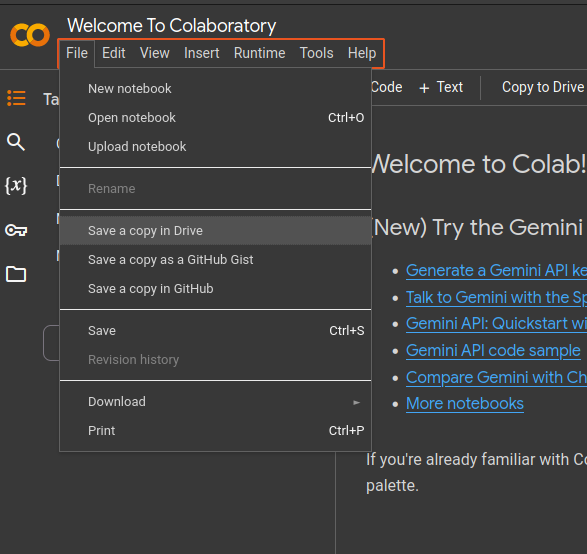

Hãy tiếp tục với notebook mà bạn đã copy về Drive.

## Giới thiệu

### LeNet

Trong notebook này bạn sẽ được trải nghiệm cài đặt mạng LeNet [(LeCun et al. 1989)](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf) cho bài toán Nhận dạng chữ số viết tay.

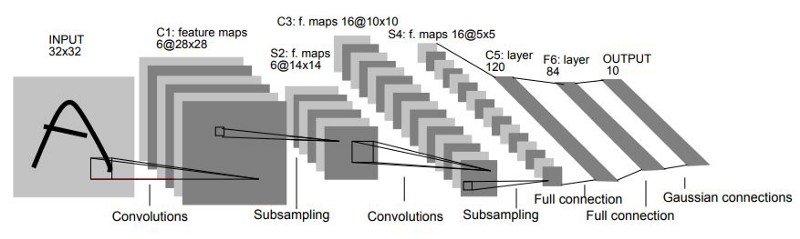

Mạng LeNet gồm 2 lớp CNN, 2 lớp subsampling, sau cùng là 2 lớp fully-connected. Tuy kiến trúc tương đối đơn giản nhưng lại mang lại hiệu quả đáng kể.

[https://www.youtube.com/watch?v=FwFduRA_L6Q](https://www.youtube.com/watch?v=FwFduRA_L6Q)

Đây là video demo của mạng LeNet vào năm 1993, trong video bạn có thể thấy Yann LeCun (giải Turing 2018) -- tác giả của LeNet cùng các đồng sự tại Bell Labs.

### MNIST

MNIST Handwritten Digit Dataset là bộ dữ liệu đã được gán nhãn, trong đó tập train gồm 60000 mẫu và tập test 10000 mẫu là ảnh các chữ số viết tay, đã được gán nhãn.

Trong lab này, ta sẽ dùng [MNIST dataset từ torchvision](https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html). Ngoài MNIST, thư viện torchvision còn cung cấp rất nhiều dataset cho các task Computer Vision, bạn có thể xem [ở đây](https://pytorch.org/vision/0.17/datasets.html)

## Cài đặt các package cần thiết

Chúng ta sẽ cài đặt LeNet5 trên framework pytorch, sử dụng dataset MNIST từ torchvision.

In [ ]:
!pip install torch==2.2.2
!pip install torchvision==0.17.2

## Import các package cần thiết

In [ ]:
import torch, torchvision

## Một số cài đặt cho quá trình huấn luyện

In [ ]:
# Kích thước một batch
batch_size = 64

# Số lượng training epoch
num_epochs = 1

# Learning rate
learning_rate = 0.001

## Set seed

Để đảm bảo kết quả training & testing thống nhất mà không ảnh hưởng bởi yếu tố random, ta nên set random seed cho pytorch, python random và numpy

In [ ]:
import random
import numpy as np

random_state = 42

torch.manual_seed(random_state)
random.seed(random_state)
np.random.seed(random_state)

## Dataset & dataloader

Ta xem qua vài mẫu của bộ dữ liệu MNIST:

In [ ]:
# Load bộ dữ liệu MNIST
train_dataset_example = torchvision.datasets.MNIST(
    root="./data",                                # Lưu ở folder /data
    train=True,                                   # Load tập train
    download=True                                 # Download data nếu không có sẵn
)

In [ ]:
for i in range(10):
    image, label = train_dataset_example[i]
    display(image)
    print(f"Label: {label}")
    print("===")

Label: 5
===


Label: 0
===


Label: 4
===


Label: 1
===


Label: 9
===


Label: 2
===


Label: 1
===


Label: 3
===


Label: 1
===


Label: 4
===


Ta cần chia dataset thành các batch và load vào model trong mỗi lượt train. Đầu tiên, ta cần download và thực hiện các bước preprocessing trên dataset MNIST

In [ ]:
# Load training dataset của bộ MNIST
train_dataset = torchvision.datasets.MNIST(
    root="./data",                                # Lưu ở folder /data
    train=True,                                   # Load tập train
    transform=torchvision.transforms.Compose([    # Thực hiện các bước preprocessing
        torchvision.transforms.Resize((32, 32)),  # Resize ảnh về 32x32 (cho hợp với kiến trúc LeNet)
        torchvision.transforms.ToTensor(),        # Chuyển ảnh về dạng Tensor
        torchvision.transforms.Normalize(         # Normalize ảnh từ [0-255] về [0-1]
            mean=(.1307,),
            std=(.3081,)
        )
    ]),
    download=True                                 # Download data nếu không có sẵn
)

# Tương tự như train_dataset, đoạn code này download bộ test của tập MNIST
test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,                                  # Load tập test
    transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((32, 32)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(
            mean=(.1325,),
            std=(.3105,)
        )
    ]),
    download=True
)


Ở đây có vài chỗ "lạ": `0.1307` và `0.3081` ở `torchvision.transforms.Normalize` ở đâu ra?

<details>
<summary>Câu trả lời</summary>
đây là mean và std của tập train, được tính sẵn.

https://discuss.pytorch.org/t/normalization-in-the-mnist-example/457

Tương tự với tập test, các con số `0.1325` và `0.3105` lần lượt là mean và std của tập **test**.
</details>
    
Khi đã có các tập train và test rồi, ta tạo dataloader để chia các tập này thành các batch, shuffle (trộn) để tránh việc model "học thuộc" các sample gây overfit.

Ta xem qua vài mẫu của tập train & tập test trong dataset (sau khi thêm bước `transform`):

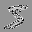

Label: 5
===


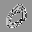

Label: 0
===


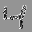

Label: 4
===


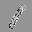

Label: 1
===


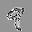

Label: 9
===


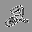

Label: 2
===


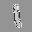

Label: 1
===


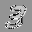

Label: 3
===


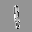

Label: 1
===


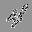

Label: 4
===


In [ ]:
for i in range(10):
    image, label = train_dataset[i]
    display(torchvision.transforms.functional.to_pil_image(image))
    print(f"Label: {label}")
    print("===")

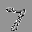

Label: 7
===


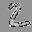

Label: 2
===


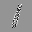

Label: 1
===


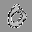

Label: 0
===


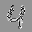

Label: 4
===


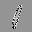

Label: 1
===


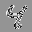

Label: 4
===


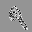

Label: 9
===


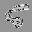

Label: 5
===


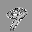

Label: 9
===


In [ ]:
for i in range(10):
    image, label = test_dataset[i]
    display(torchvision.transforms.functional.to_pil_image(image))
    print(f"Label: {label}")
    print("===")

Như bạn thấy, sau khi norm hình có vẻ "khó nhìn" hơn, tuy nhiên máy lại dễ học hơn (!).

Ta tạo dataloader để chia dataset thành các batch để load vào model:

In [ ]:
train_dataloader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    shuffle=True,
    batch_size=batch_size
)

test_dataloader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    shuffle=True,
    batch_size=batch_size
)

## Train với GPU hay CPU?

Với pytorch, bạn cần chỉ rõ ra là bạn dùng CPU hay GPU để train. Đoạn code sau sẽ xác định giùm bạn:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cpu')

**Chú ý**: lát nữa ta sẽ thử train bằng GPU, yên tâm.

## Model

Thử "đọc hiểu" kiến trúc LeNet dưới đây:

In [ ]:
class LeNet5(torch.nn.Module):
    def __init__(self, **kwargs):
        super(LeNet5, self).__init__()

        # Total classes in the problem
        self.num_classes = kwargs.get("num_classes", 10)

        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels=1,
                out_channels=6,
                kernel_size=5
            ),
            torch.nn.BatchNorm2d(6),
            torch.nn.Sigmoid(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(                                # Lớp Convo thứ 2 của LeNet
                in_channels=6,
                out_channels=16,
                kernel_size=5
            ),
            torch.nn.BatchNorm2d(16),                       # Batch norm = size của out channel
            torch.nn.Sigmoid(),                             # Sigmoid activation
            torch.nn.MaxPool2d(kernel_size=2, stride=2),    # Max pooling theo đúng config của LeNet
        )

        self.fc1 = torch.nn.Linear(400, 120)                # 400 ở đâu ra?
        self.fc2 = torch.nn.Linear(120, 84)
        self.fc3 = torch.nn.Linear(84, self.num_classes)
        self.activation = torch.nn.Sigmoid()

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = torch.flatten(out, 1)                         # Convert tensor [batch_size, 16, 5, 5] về [batch_size, 400]
        out = self.fc1(out)
        out = self.activation(out)
        out = self.fc2(out)
        out = self.activation(out)
        out = self.fc3(out)

        return out

Câu hỏi: 400 trong input của fully-connected layer 1 ở đâu ra?

<details>
<summary>Câu trả lời</summary>

Output có 16 channel, kích thước $5\times 5$, do đó $16\times 5\times 5 = 400$ là input của fully connected layer.
    
[Link công cụ tính](http://layer-calc.com/)
    
</details>

In [ ]:
# Model
model = LeNet5(classes=10).to(device)

In [ ]:
# Hàm loss - CrossEntropy
loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
# Optimizer - ở đây dùng Adam
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Số step train -- dùng lúc log cho vui thôi vì mình train theo epoch
total_steps = len(train_dataloader)

Đọc thêm:

- Adam optimizer:  https://pytorch.org/docs/stable/generated/torch.optim.Adam.html
- Cross entropy loss: https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

## Training

In [ ]:
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i % 100 == 0):
            print(f"Epoch: {epoch + 1}/{num_epochs} | Step: {i + 1}/{total_steps} | Loss: {loss.item():.4f}")

Epoch: 1/1 | Step: 1/938 | Loss: 2.3164
Epoch: 1/1 | Step: 101/938 | Loss: 1.9427
Epoch: 1/1 | Step: 201/938 | Loss: 1.0291
Epoch: 1/1 | Step: 301/938 | Loss: 0.7104
Epoch: 1/1 | Step: 401/938 | Loss: 0.5340
Epoch: 1/1 | Step: 501/938 | Loss: 0.3525
Epoch: 1/1 | Step: 601/938 | Loss: 0.2104
Epoch: 1/1 | Step: 701/938 | Loss: 0.2521
Epoch: 1/1 | Step: 801/938 | Loss: 0.1722
Epoch: 1/1 | Step: 901/938 | Loss: 0.1501


## Testing

In [ ]:
with torch.no_grad():
    correct_predictions = 0
    total_samples = 0

    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predictions == labels).sum().item()

    test_accuracy = correct_predictions / total_samples
    print(f"Testing accuracy: {test_accuracy:.4f}")

Testing accuracy: 0.9639


**Chú ý**: nếu bạn **không set seed** hoặc **đổi seed từ 42 thành một con số khác**, testing accuracy và kết quả các cells bên dưới có thể thay đổi!

## Visualizing confusion matrix

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
test_predictions = []
test_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = model(images)

        _, predictions = torch.max(outputs.data, 1)

        test_predictions.extend(predictions.tolist())

        test_labels.extend(labels.tolist())

In [ ]:
print(classification_report(test_predictions, test_labels))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1030
           1       0.98      1.00      0.99      1114
           2       0.97      0.94      0.96      1063
           3       0.96      0.96      0.96      1018
           4       0.97      0.97      0.97       983
           5       0.95      0.96      0.96       883
           6       0.97      0.97      0.97       961
           7       0.95      0.97      0.96      1004
           8       0.94      0.98      0.96       939
           9       0.95      0.95      0.95      1005

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



Mô hình cho kết quả khá tốt dù chỉ train với 1 epoch, overall accuracy trên tập test đạt 0.96 là một con số khá cao. Tuy nhiên ta nên chú ý, vì tập MNIST là tập khá dễ học (với máy), nên LeNet chưa bộc lộ các khuyết điểm của nó.

[]

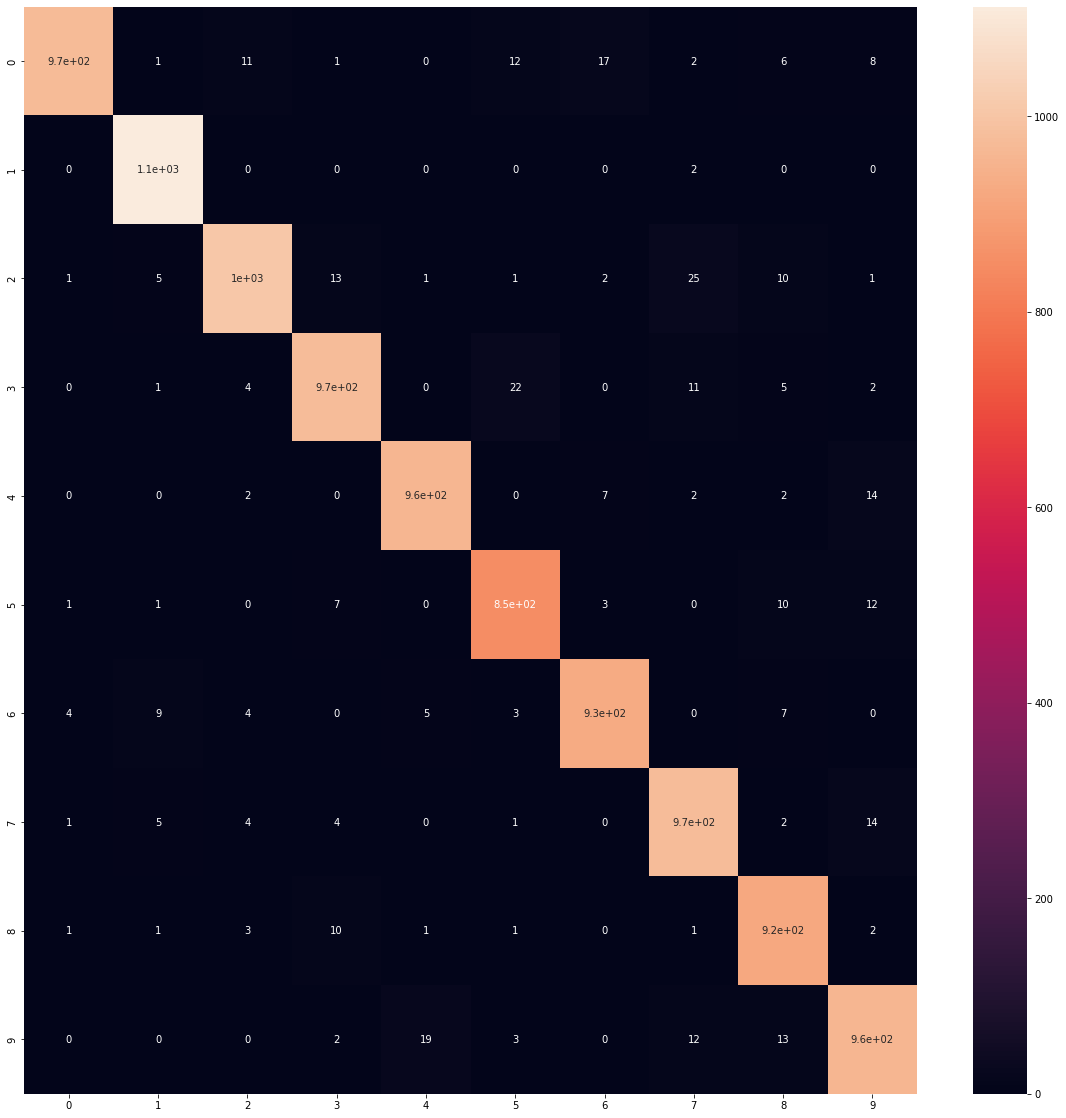

In [ ]:
fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(confusion_matrix(test_predictions, test_labels), annot=True, ax=ax)
plt.plot()

## Sử dụng GPU cho quá trình training

Bạn để ý bên góc trên tay phải, nhấn nút mũi tên cạnh ô "Connect" > Change runtime type

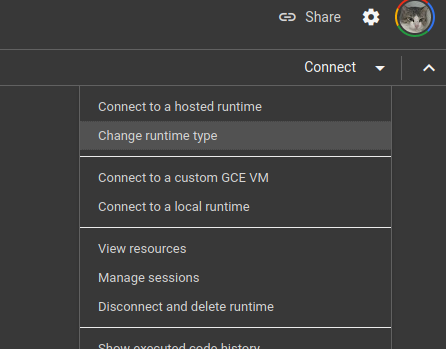

Chọn `T4 GPU` và nhấn `Save`.

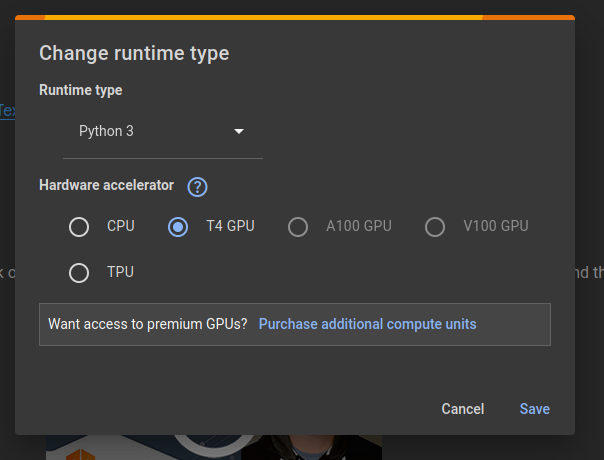

Sau khi notebook kết nối lại với runtime, bạn thử chạy lại notebook từ đầu: `Runtime > Run all` và để ý thời gian train.

Now it's your turn!

## Yêu cầu:

Bạn được lựa chọn cài đặt các mô hình (1) AlexNet  [(Khirzhevsky et al. 2012)](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf) hoặc (2) VGG16  [(Simonyan et al. 2014)](https://arxiv.org/abs/1409.1556).

1. Nếu bạn cài đặt AlexNet, mở file `alexnet.ipynb` để xem các task cụ thể.
2. Nếu bạn cài đặt VGG16, mở file `vgg16.ipynb` để xem các task cụ thể.

## Nộp bài

Bạn được yêu cầu nộp **1 trong 2 bài** theo quy tắc đặt tên đã quy định trong các notebook bên trên. Nếu có thời gian, bạn nên thử cài đặt mô hình còn lại trong bài tập này để luyện tập thêm.

Chúc thành công!